# Raisin Detective – Feature Importance and Permutation Importance

In this notebook, we analyze which features are most important for the Random Forest model.

We compare two types of importance:

- Feature Importance from the Random Forest model
- Permutation Importance based on model performance

The goal is to understand which raisin measurements contribute most to classifying Kecimen and Besni.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [3]:
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

csv_path = DATA_RAW / "raisin_dataset.csv"

df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
X = df.drop(columns="Class")
y = df["Class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping

{'Besni': np.int64(0), 'Kecimen': np.int64(1)}

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (720, 7)
X_test shape: (180, 7)


In [6]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.8722


In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,Perimeter,0.269561
1,MajorAxisLength,0.229340
4,ConvexArea,0.156957
0,Area,0.133450
3,Eccentricity,0.083552
2,MinorAxisLength,0.071079
5,Extent,0.056060


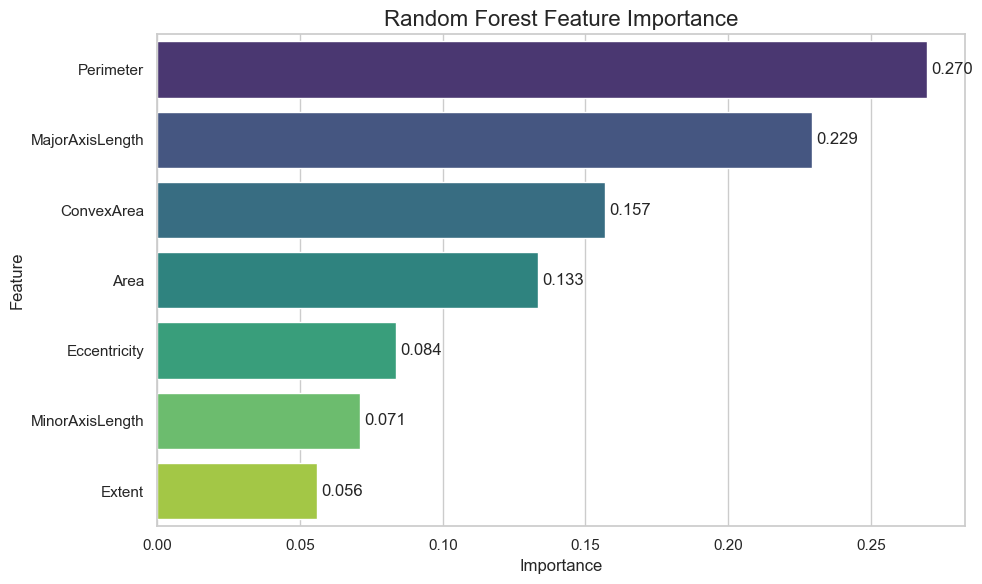

In [8]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## Random Forest Feature Importance

Random Forest feature importance shows which variables the model used most often and most effectively when making splits in the trees.

Features with higher importance values contributed more to reducing uncertainty in the model.

However, this type of importance can be biased toward variables with many possible split points or variables that are strongly correlated with others. Therefore, we also use Permutation Importance for comparison.

In [9]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

permutation_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
}).sort_values(by="Importance Mean", ascending=False)

permutation_df

,Feature,Importance Mean,Importance Std
6,Perimeter,0.135833,0.023272
1,MajorAxisLength,0.021111,0.012741
5,Extent,0.010278,0.007911
3,Eccentricity,-0.000278,0.007753
4,ConvexArea,-0.000278,0.004803
2,MinorAxisLength,-0.002778,0.004120
0,Area,-0.003333,0.004779


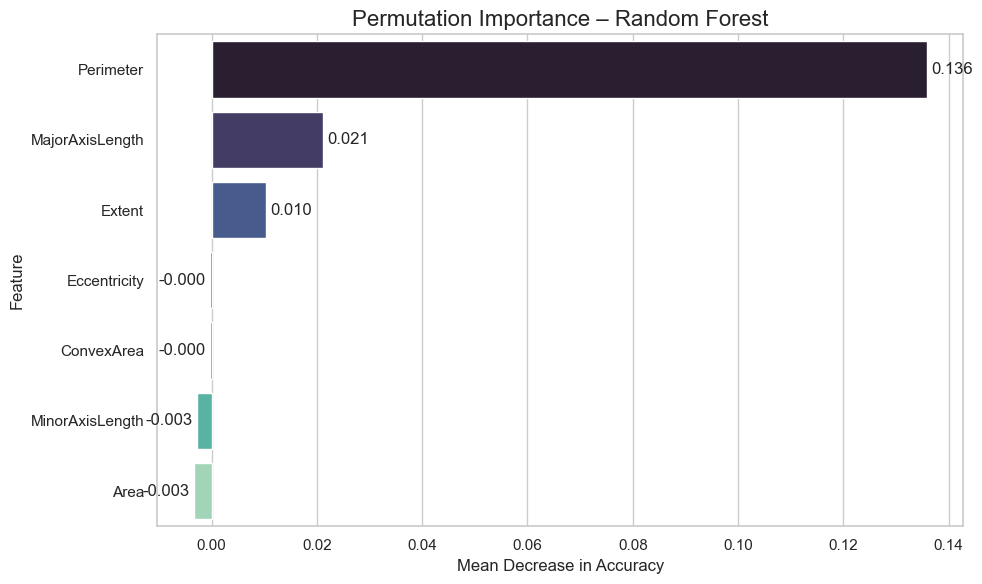

In [10]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=permutation_df,
    x="Importance Mean",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.title("Permutation Importance – Random Forest")
plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## Permutation Importance

Permutation Importance measures how much the model performance decreases when one feature is randomly shuffled.

If shuffling a feature causes a large decrease in accuracy, it means that the feature is important for the model's predictions.

Compared to the built-in Random Forest feature importance, Permutation Importance is more directly connected to the model's actual predictive performance on test data.

In [11]:
importance_comparison = feature_importance.merge(
    permutation_df,
    on="Feature",
    how="inner"
)

importance_comparison = importance_comparison.rename(columns={
    "Importance": "RF Feature Importance",
    "Importance Mean": "Permutation Importance"
})

importance_comparison = importance_comparison.sort_values(
    by="Permutation Importance",
    ascending=False
)

importance_comparison

,Feature,RF Feature Importance,Permutation Importance,Importance Std
0,Perimeter,0.269561,0.135833,0.023272
1,MajorAxisLength,0.229340,0.021111,0.012741
6,Extent,0.056060,0.010278,0.007911
2,ConvexArea,0.156957,-0.000278,0.004803
4,Eccentricity,0.083552,-0.000278,0.007753
5,MinorAxisLength,0.071079,-0.002778,0.004120
3,Area,0.133450,-0.003333,0.004779


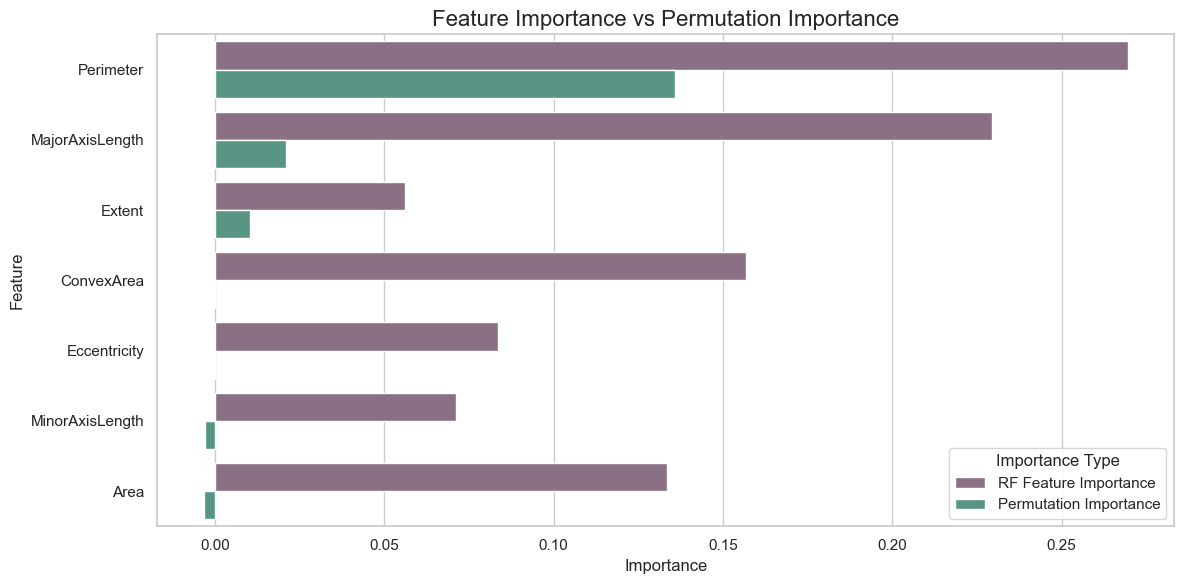

In [12]:
comparison_plot = importance_comparison.melt(
    id_vars="Feature",
    value_vars=["RF Feature Importance", "Permutation Importance"],
    var_name="Importance Type",
    value_name="Importance"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_plot,
    x="Importance",
    y="Feature",
    hue="Importance Type",
    palette=["#8E6C88", "#4E9F8A"]
)

plt.title("Feature Importance vs Permutation Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend(title="Importance Type")

plt.tight_layout()
plt.show()

## Importance Comparison Summary

The comparison between Random Forest Feature Importance and Permutation Importance helps us identify the most reliable features.

Features that appear important in both methods are more trustworthy because they are important both during model training and for actual predictive performance.

In the Raisin dataset, size and shape-related variables such as Perimeter, MajorAxisLength, Area or ConvexArea may be expected to play an important role because they describe the physical structure of the raisins.

## Interpretation of Feature Importance Results

The Random Forest Feature Importance shows that Perimeter, MajorAxisLength, ConvexArea and Area are the most important features during model training. These variables describe the size and shape of the raisins, which makes sense for classifying Kecimen and Besni.

However, the Permutation Importance gives a more direct view of how much each feature affects the model's predictive performance on test data. In this analysis, Perimeter is clearly the most important feature. MajorAxisLength also contributes positively, while Extent has a smaller positive effect.

Some features, such as Area and ConvexArea, have low or slightly negative permutation importance. This does not necessarily mean that they are useless. The correlation heatmap showed that several size-related variables are strongly correlated. Therefore, the model may already capture similar information through Perimeter, which makes the additional contribution of correlated variables smaller.

Overall, Perimeter appears to be the most reliable and important feature for distinguishing between the two raisin classes.